In [1]:
import sys
sys.version



'3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]'

In [2]:
!pip install tensorflow

In [3]:
!pip install keras

In [4]:
from zipfile import ZipFile
file_name = "Face-Images.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
TrainingImagePath = "/content/Face Images/Final Training Images"

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True)

validation_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
        TrainingImagePath,
        target_size=(64, 64),
        batch_size=32,
        class_mode='categorical')

validation_set = validation_datagen.flow_from_directory(
        TrainingImagePath,
        target_size=(64, 64),
        batch_size=32,
        class_mode='categorical')

validation_set.class_indices

Found 244 images belonging to 16 classes.
Found 244 images belonging to 16 classes.


{'face1': 0,
 'face10': 1,
 'face11': 2,
 'face12': 3,
 'face13': 4,
 'face14': 5,
 'face15': 6,
 'face16': 7,
 'face2': 8,
 'face3': 9,
 'face4': 10,
 'face5': 11,
 'face6': 12,
 'face7': 13,
 'face8': 14,
 'face9': 15}

In [6]:
TrainClasses=training_set.class_indices

ResultMap  = {}
for faceName, faceValue in TrainClasses.items():
  ResultMap[faceValue] = faceName

In [7]:
import pickle
with open("ResultsMap.pkl", 'wb') as f:
  pickle.dump(ResultMap, f, pickle.HIGHEST_PROTOCOL)

print("Mapping of Face and its ID saved", ResultMap)

Mapping of Face and its ID saved {0: 'face1', 1: 'face10', 2: 'face11', 3: 'face12', 4: 'face13', 5: 'face14', 6: 'face15', 7: 'face16', 8: 'face2', 9: 'face3', 10: 'face4', 11: 'face5', 12: 'face6', 13: 'face7', 14: 'face8', 15: 'face9'}


In [8]:
OutputNeurons = len(ResultMap)
print('\n The number of output neurons:',OutputNeurons)


 The number of output neurons: 16


In [9]:
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense

classifier = Sequential()

classifier.add (Convolution2D(filters=10, kernel_size = (3, 3), strides = (1,1), input_shape = (64, 64, 3), activation='relu'))

classifier.add (MaxPooling2D(pool_size=(2,2)))

classifier.add (Convolution2D(filters=10, kernel_size = (5, 5), strides = (2,2), activation='relu'))

classifier.add (MaxPooling2D(pool_size=(2,2)))

classifier.add (Flatten())

classifier.add (Dense(units=128, activation='relu'))

classifier.add (Dense(OutputNeurons, activation='softmax'))

classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 10)     │         2,510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 490)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        62,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,702 (264.46 KB)

 Trainable params: 67,702 (264.46 KB)

 Non-trainable params: 0 (0.00 B)

**Fitting the model**


In [11]:
import time

StartTime = time.time()

classifier.fit(
        training_set,
        steps_per_epoch = 8,
        epochs = 60,
        validation_data = validation_set,
        validation_steps = 4)

EndTime = time.time()
print("###### Total Time Taken: ", round((EndTime - StartTime)/60), 'Minutes ######')

Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 356ms/step - accuracy: 0.0738 - loss: 2.7966 - val_accuracy: 0.0859 - val_loss: 2.7460
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.0984 - loss: 2.7561 - val_accuracy: 0.1016 - val_loss: 2.7391
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.1270 - loss: 2.7374 - val_accuracy: 0.0625 - val_loss: 2.7173
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.1189 - loss: 2.7026 - val_accuracy: 0.1875 - val_loss: 2.6202
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.1721 - loss: 2.6487 - val_accuracy: 0.1719 - val_loss: 2.5972
Epoch 6/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 0.2623 - loss: 2.5713 - val_accuracy: 0.3516 - val_loss: 2.4353
Epoch 7/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.3730 - loss: 2.4466 - val_accuracy: 0.5703 - val_loss: 2.2130
Epoch 8/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.4508 - loss: 2.2781 - val_accuracy: 0.4609 - val_loss

**Saving the model**

In [12]:
classifier.save("classifier.keras")

**Testing the model on a different face**

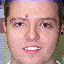

In [13]:
import numpy as np
from keras.preprocessing import image

test_image = image.load_img("/content/Face Images/Final Testing Images/face4/3face4.jpg", target_size=(64, 64))
test_image

In [14]:
print('### Converting the image into a numeric array ###')
test_image_array = image.img_to_array(test_image)
print(test_image_array,'\n')

print('### Reshaping the array as one single sample for prediction ###')
test_image_array_exp_dim = np.expand_dims(test_image_array, axis=0)
print(test_image_array_exp_dim.shape,'\n')

result = classifier.predict(test_image_array_exp_dim,verbose=0)

print('### Printing probabilities for each class ###')
print(result,'\n')

print('### Printing originl face mapping ###')
print(ResultMap,'\n')

print('###'*10)
print('Prediction: This is a ',ResultMap[np.argmax(result)])

### Converting the image into a numeric array ###
[[[ 52.  49. 152.]
  [ 82.  79. 146.]
  [104.  97. 149.]
  ...
  [ 42.  35.  89.]
  [  0.   0.  56.]
  [  0.   0.  62.]]

 [[ 32.  28. 102.]
  [100.  90. 114.]
  [ 74.  69.  75.]
  ...
  [ 31.  26.  23.]
  [ 10.   7.  14.]
  [  0.   0.  24.]]

 [[ 29.  23.  83.]
  [ 65.  53.  67.]
  [106.  98.  95.]
  ...
  [ 37.  27.  25.]
  [ 58.  49.  42.]
  [ 10.   8.  11.]]

 ...

 [[170. 180. 233.]
  [168. 177. 176.]
  [162. 170. 159.]
  ...
  [ 86.  90.  65.]
  [ 98. 107.  90.]
  [122. 131. 130.]]

 [[169. 174. 229.]
  [165. 174. 171.]
  [167. 175. 164.]
  ...
  [ 90.  92.  68.]
  [118. 127. 110.]
  [108. 116. 118.]]

 [[148. 153. 217.]
  [157. 165. 178.]
  [167. 171. 170.]
  ...
  [ 84.  88.  73.]
  [ 92.  96.  81.]
  [115. 131. 131.]]] 

### Reshaping the array as one single sample for prediction ###
(1, 64, 64, 3) 

### Printing probabilities for each class ###
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]] 

### Printing originl face map